# Traffic analysis

Read and process PCAPs recorded during AI agent execution, provide basic statistics.

In [40]:
import pandas as pd
import os
import pcap_tools as pt
from pathlib import Path
import random
from tqdm import tqdm

import seaborn as sns
import matplotlib.pyplot as plt

SAVE_DIR = "./Results/plots/"
SAVE_PLOTS = True

AGENT_TYPE = "no-tools_random"  # weather # research-assistant
SET_TYPE = "test"  # train, test
PCAP_DIR = f"/Users/azza/Desktop/AI agents/single_agent/{AGENT_TYPE}_{SET_TYPE}/pcap/"
CLIENT_IP = "172.17.0.2"


In [7]:
sns.set_theme(
    style="whitegrid",
    context="paper",   # or "notebook"
    font_scale=1.0
)

In [20]:
import re

pcap_file_name_pattern = re.compile(r'^(?:no-tools|weather|research-assistant)-([^-]+)-(.+?)-(\d{8}-\d{6})\.pcap$')

def extract_agent_from_filename(filename):
    m = pcap_file_name_pattern.match(filename)
    if not m:
        raise ValueError(f"Invalid filename format: {filename}")
    value1, value2, value3 = m.groups()
    return value1, value2, value3

# Multi-agent data

In [21]:
results = []

for prompt in ["no-tools", "weather", "research"]:
    prompt_dir = os.path.join(f"/Users/azza/Desktop/AI agents/multi_agent/pcaps/", f"{prompt}")

    files = [p for p in Path(prompt_dir).iterdir() 
            if p.is_file() and p.suffix.lower() in (".pcap", ".pcapng")]
    
    rng = random.Random(42)
    rng.shuffle(files)
    
    files = files[:300]  # Limit to first 'x' files for quicker processing

    for p in tqdm(files, desc=f"Processing {prompt_dir}"):
        backend, model, dt = extract_agent_from_filename(p.name)
        analysis = pt.analyze_pcap(p, client_ip = CLIENT_IP)
        analysis["prompt"] = prompt
        analysis["backend"] = backend
        analysis["model"] = model
        analysis["datetime"] = dt
        results.append(analysis)

multi_df = pd.DataFrame(results)

Processing /Users/azza/Desktop/AI agents/multi_agent/pcaps/no-tools: 100%|██████████| 205/205 [00:47<00:00,  4.29it/s]
Processing /Users/azza/Desktop/AI agents/multi_agent/pcaps/weather: 100%|██████████| 193/193 [01:39<00:00,  1.93it/s]
Processing /Users/azza/Desktop/AI agents/multi_agent/pcaps/research: 100%|██████████| 202/202 [13:33<00:00,  4.03s/it]  


## Volume, latency

In [17]:
results = []

for prompt in ["no-tools", "weather", "research"]:
    prompt_dir = os.path.join(f"/Users/azza/Desktop/AI agents/single_agent/", f"{prompt}_agent_train/pcap")
    
  

    files = [p for p in Path(prompt_dir).iterdir() 
            if p.is_file() and p.suffix.lower() in (".pcap", ".pcapng")]
    
    rng = random.Random(42)
    rng.shuffle(files)
    
    files = files[:300]  # Limit to first 'x' files for quicker processing

    for p in tqdm(files, desc=f"Processing {prompt_dir}"):
        backend, model, dt = pt.extract_agent_from_filename(p.name)
        analysis = pt.analyze_pcap(p, client_ip = CLIENT_IP)
        analysis["prompt"] = prompt
        analysis["backend"] = backend
        analysis["model"] = model
        analysis["datetime"] = dt
        results.append(analysis)

single_df = pd.DataFrame(results)

Processing /Users/azza/Desktop/AI agents/single_agent/no-tools_agent_train/pcap: 100%|██████████| 300/300 [00:51<00:00,  5.81it/s]
Processing /Users/azza/Desktop/AI agents/single_agent/weather_agent_train/pcap: 100%|██████████| 281/281 [01:20<00:00,  3.48it/s]
Processing /Users/azza/Desktop/AI agents/single_agent/research_agent_train/pcap: 100%|██████████| 56/56 [02:09<00:00,  2.32s/it]


In [22]:
single_df=results_df

In [18]:
def boxplot_y(y):
    """
    Create two separate figures (same height) for:
      - no-tools and weather shown side-by-side (hue='prompt')
      - research alone
    Requires results_df, sns, plt, SAVE_PLOTS, SAVE_DIR to be available in the notebook.
    """
    if y not in results_df.columns:
        raise ValueError(f"Column '{y}' not found in results_df")

    order = sorted(results_df["backend"].unique())
    box_width = 0.6
    height = 5
    figsize = (8, height)

    first_prompts = ["no-tools", "weather"]
    second_prompts = ["research"]

    subset1 = results_df[results_df["prompt"].isin(first_prompts)]
    subset2 = results_df[results_df["prompt"].isin(second_prompts)]

    if y == "latency":
        y_label = "Latency [s]"
    elif y == "sent":
        y_label = "Data Sent [kB]"
    elif y == "received":
        y_label = "Data Received [kB]"
    elif y == "streams":
        y_label = "# TCP streams"
    else:
        y_label = y

    # Figure 1: no-tools and weather side-by-side using hue
    fig1, ax1 = plt.subplots(figsize=(5,4))
    if not subset1.empty:
        sns.boxplot(data=subset1, x="backend", y=y, hue="prompt", order=order,
                    width=box_width, palette="Set2", ax=ax1)
        #ax1.set_title("no-tools vs weather")
        ax1.set_xlabel(None)
        ax1.set_ylabel(y_label)
        #ax1.set_ylim(ylim)
        ax1.grid(axis="y", alpha=0.3)
        ax1.legend(title="Agent")
    else:
        ax1.text(0.5, 0.5, "No data for no-tools/weather", ha="center")
    fig1.tight_layout()
    if SAVE_PLOTS:
        fig1.savefig(f"{SAVE_DIR}boxplot_{y}_no-tools_weather.png", dpi=300)
    plt.show()

    # Figure 2: research only
    fig2, ax2 = plt.subplots(figsize=(3,4))
    if not subset2.empty:
        sns.boxplot(data=subset2, x="backend", y=y, order=order,
                    width=box_width, ax=ax2)
        #ax2.set_title("research")
        ax2.set_xlabel(None)
        ax2.set_ylabel(y_label)
        #ax2.set_ylim(ylim)
        ax2.grid(axis="y", alpha=0.3)
        ax2.legend(title="Agent", labels=["research"])
    else:
        ax2.text(0.5, 0.5, "No data for research", ha="center")
    fig2.tight_layout()
    if SAVE_PLOTS:
        fig2.savefig(f"{SAVE_DIR}boxplot_{y}_research.png", dpi=300)
    plt.show()

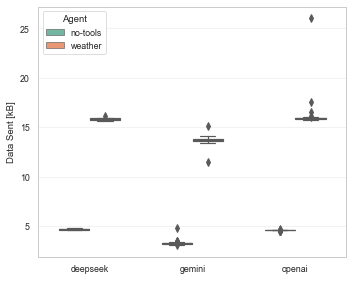

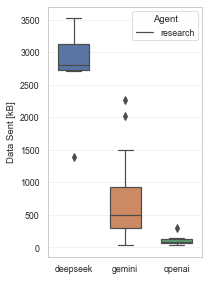

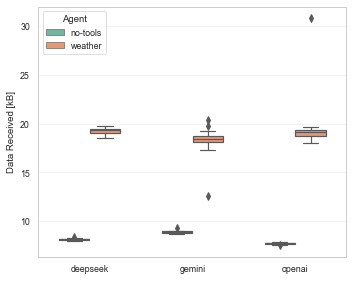

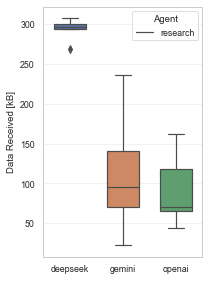

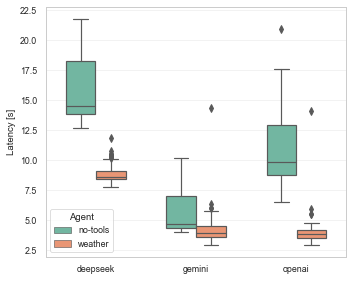

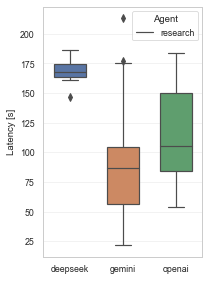

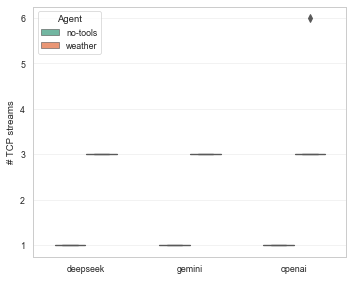

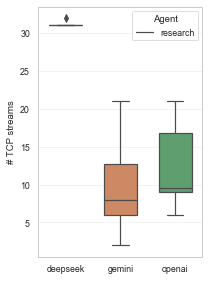

In [19]:
boxplot_y("sent")
boxplot_y("received")
boxplot_y("latency")
boxplot_y("streams")

<Figure size 576x360 with 0 Axes>

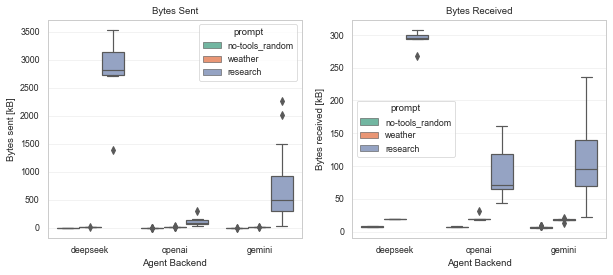

In [16]:
plt.figure(figsize=(8,5))
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.boxplot(data=results_df, x="backend", y="sent", hue="prompt", palette="Set2", ax=axes[0])
axes[0].set_title("Bytes Sent")
axes[0].set_xlabel("Agent Backend")
axes[0].set_ylabel("Bytes sent [kB]")
axes[0].grid(axis="y", alpha=0.3)

sns.boxplot(data=results_df, x="backend", y="received", hue="prompt", palette="Set2", ax=axes[1])
axes[1].set_title("Bytes Received")
axes[1].set_xlabel("Agent Backend")
axes[1].set_ylabel("Bytes received [kB]")
axes[1].grid(axis="y", alpha=0.3)


## Burstiness

Analyze traffic burst:
- the number
- burst duration
- distribution within defined intervals

In [43]:
WINDOW_SIZE = 0.01  # seconds
MAX_MATRIX_LEN = 18000  # max number of windows in MTAM

results = []

for prompt in ["no-tools", "weather", "research"]:
    prompt_dir = os.path.join(f"/Users/azza/Desktop/AI agents/multi_agent/pcaps/", f"{prompt}")

    files = [p for p in Path(prompt_dir).iterdir() 
            if p.is_file() and p.suffix.lower() in (".pcap", ".pcapng")]
    
    rng = random.Random(42)
    rng.shuffle(files)
    files = files[:100]  # Limit to first 'x' files for quicker processing

    for p in tqdm(files, desc=f"Processing {prompt_dir}"):
        backend, model, dt = extract_agent_from_filename(p.name)
        packet_trace = pt.pcap_to_trace_scapy(str(p), client_ip = CLIENT_IP)
        analysis = pt.burst_analysis(packet_trace)
        analysis["prompt"] = prompt
        analysis["backend"] = backend
        analysis["model"] = model
        analysis["datetime"] = dt

        # Reuse mtam for short burst analysis
        mtam = pt.build_mtam(packet_trace, window_size=WINDOW_SIZE, num_windows=MAX_MATRIX_LEN)
        window_bursts = pt.window_bursts(mtam)
        analysis["window_bursts"] = window_bursts
        results.append(analysis)


burst_df = pd.DataFrame(results)

Processing /Users/azza/Desktop/AI agents/multi_agent/pcaps/no-tools:   6%|▌         | 6/100 [00:00<00:03, 26.68it/s]

*** Warning: less than 80% of packets involve client_ip='172.17.0.2' (37 out of 50)
*** Warning: less than 80% of packets involve client_ip='172.17.0.2' (59 out of 81)


Processing /Users/azza/Desktop/AI agents/multi_agent/pcaps/no-tools:  16%|█▌        | 16/100 [00:00<00:02, 28.52it/s]

*** Warning: less than 80% of packets involve client_ip='172.17.0.2' (58 out of 76)
*** Warning: less than 80% of packets involve client_ip='172.17.0.2' (70 out of 88)


Processing /Users/azza/Desktop/AI agents/multi_agent/pcaps/no-tools:  20%|██        | 20/100 [00:00<00:02, 28.46it/s]

...

*** Warning: trace length exceeds num_windows (35481 > 18000)
*** Warning: trace length exceeds num_windows (27954 > 18000)


Processing /Users/azza/Desktop/AI agents/multi_agent/pcaps/research:  98%|█████████▊| 98/100 [00:15<00:00,  6.15it/s]

*** Warning: trace length exceeds num_windows (37052 > 18000)
*** Warning: trace length exceeds num_windows (21674 > 18000)


Processing /Users/azza/Desktop/AI agents/multi_agent/pcaps/research: 100%|██████████| 100/100 [00:16<00:00,  6.24it/s]

*** Warning: trace length exceeds num_windows (26271 > 18000)


### Prepare for plotting

- Explode the bursts

In [44]:
# One row per burst
df_scatter_plot = burst_df.explode("bursts", ignore_index=True)

# Split tuple into columns
df_scatter_plot[["size", "duration"]] = pd.DataFrame(
    df_scatter_plot["bursts"].tolist(),
    index=df_scatter_plot.index
)

# Readability: drop unneeded columns
df_scatter_plot = df_scatter_plot.drop(columns=["bursts", "datetime", "window_bursts", "avg_burst_size", "avg_burst_duration"])
df_scatter_plot = df_scatter_plot.rename(columns={
    "backend": "Model",
    "prompt": "Prompt",
})

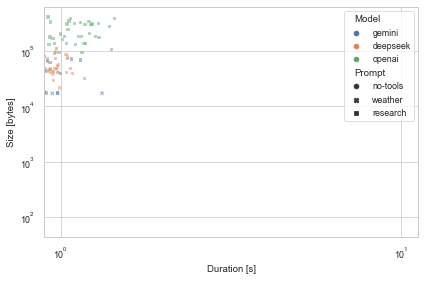

In [45]:
df_scatter_plot = df_scatter_plot.sample(frac=1, random_state=42)

plt.figure(figsize=(6, 4))

sns.scatterplot(
    data=df_scatter_plot,
    x="duration",
    y="size",
    hue="Model",
    style="Prompt",
    s = 20,
    alpha=0.5
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Duration [s]")
plt.ylabel("Size [bytes]")
plt.title(None) # "Burst Size vs Duration (colored by model and prompt)")
plt.tight_layout()

if SAVE_PLOTS:
    plt.savefig(f"{SAVE_DIR}burst_size_vs_duration.png", dpi=300)
plt.show()

In [46]:
df_window_plot = burst_df.explode("window_bursts", ignore_index=True)

df_window_plot["burst_bw"] = df_window_plot["window_bursts"] / WINDOW_SIZE *8 / 1024/1024  # in MB/s

# Readability: drop unneeded columns
df_window_plot = df_window_plot.drop(columns=["bursts", "datetime", "window_bursts", "avg_burst_size", "avg_burst_duration"])
df_window_plot = df_window_plot.rename(columns={
    "backend": "Model",
    "prompt": "Prompt",
})

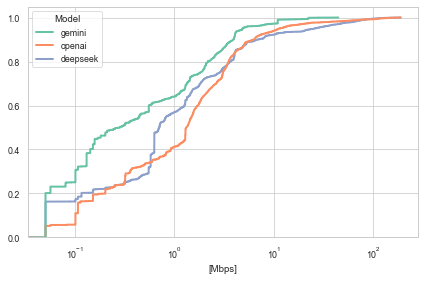

In [48]:
plt.figure(figsize=(6, 4))

sns.ecdfplot(
    data=df_window_plot,
    x="burst_bw",
    hue="Model", 
    palette="Set2",
    linewidth=2
)

plt.xscale("log")
plt.ylim(0, 1.05)

plt.xlabel("[Mbps]")
plt.ylabel(None)

#plt.title("Empirical CDF of burst bandwidth by backend")

#plt.legend(title="Backend")

plt.tight_layout()
if SAVE_PLOTS:
    plt.savefig(f"{SAVE_DIR}burst_bandwidth_cdf_by_backend.png", dpi=300)
plt.show()

In [26]:
import re

pcap_file_name_pattern = re.compile(r'^(?:no-tools|weather|research-assistant)-([^-]+)-(.+?)-(\d{8}-\d{6})\.pcap$')

def extract_agent_from_filename(filename):
    m = pcap_file_name_pattern.match(filename)
    if not m:
        raise ValueError(f"Invalid filename format: {filename}")
    value1, value2, value3 = m.groups()
    return value1, value2, value3

In [23]:
def boxplot_y_merged(y):
    """
    Merge single_df and multi_df, then create one boxplot per metric.

    Required columns in both dataframes:
      - backend
      - prompt
      - metric column y: latency, sent, received, or streams
    """

    required_cols = {"backend", "prompt", y}

    for name, df in [("single_df", single_df), ("multi_df", multi_df)]:
        missing = required_cols - set(df.columns)
        if missing:
            raise ValueError(f"{name} is missing columns: {missing}")

    # Add execution type
    s_df = single_df.copy()
    m_df = multi_df.copy()

    s_df["execution"] = "single"
    m_df["execution"] = "multi"

    # Merge
    results_all = pd.concat([s_df, m_df], ignore_index=True)

    # Combined legend label
    results_all["agent_setting"] = (
        results_all["execution"] + " / " + results_all["prompt"]
    )

    backend_order = ["deepseek", "gemini", "openai"]
    backend_order = [
        b for b in backend_order if b in results_all["backend"].unique()
    ]

    prompt_order = ["no-tools", "weather", "research"]
    execution_order = ["single", "multi"]

    hue_order = [
        f"{e} / {p}"
        for e in execution_order
        for p in prompt_order
        if f"{e} / {p}" in results_all["agent_setting"].unique()
    ]

    if y == "latency":
        y_label = "Latency [s]"
    elif y == "sent":
        y_label = "Data Sent [kB]"
    elif y == "received":
        y_label = "Data Received [kB]"
    elif y == "streams":
        y_label = "# TCP streams"
    else:
        y_label = y

    fig, ax = plt.subplots(figsize=(9, 4.8))

    sns.boxplot(
        data=results_all,
        x="backend",
        y=y,
        hue="agent_setting",
        order=backend_order,
        hue_order=hue_order,
        width=0.75,
        ax=ax
    )

    ax.set_xlabel(None)
    ax.set_ylabel(y_label)
    ax.grid(axis="y", alpha=0.3)

    ax.legend(
        title="Execution / Agent",
        loc="upper left",
        bbox_to_anchor=(1.02, 1),
        borderaxespad=0
    )

    fig.tight_layout()

    if SAVE_PLOTS:
        fig.savefig(
            f"{SAVE_DIR}boxplot_{y}_merged_single_multi.png",
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

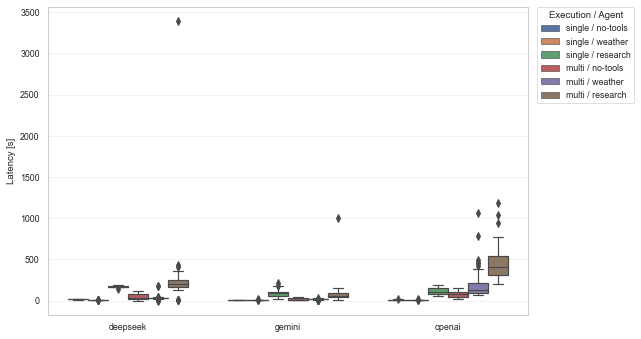

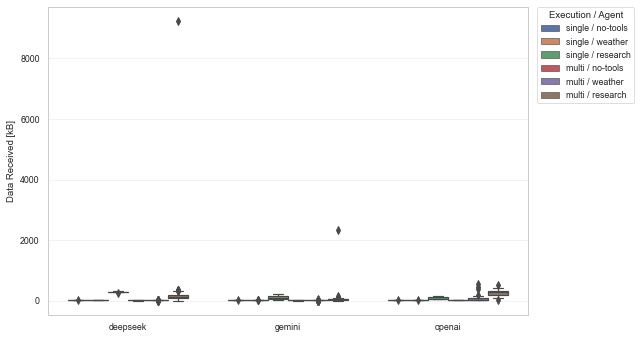

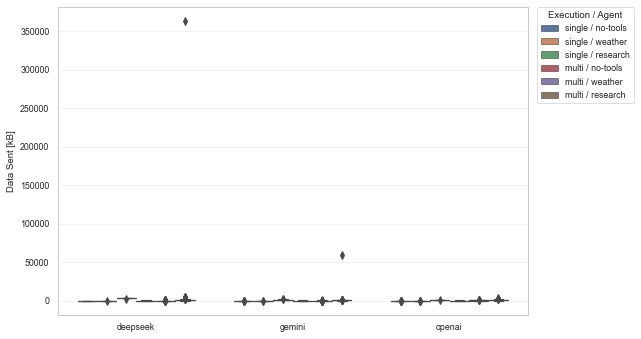

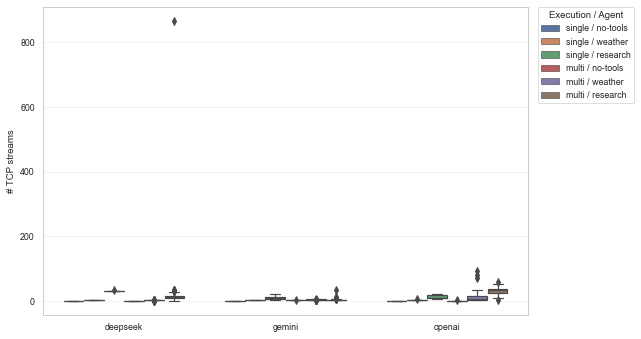

In [24]:
boxplot_y_merged("latency")
boxplot_y_merged("received")
boxplot_y_merged("sent")
boxplot_y_merged("streams")

In [25]:
def boxplot_y_single_multi_split(y):
    """
    Create two figures per metric:
      1) no-tools and weather together, comparing single vs multi
      2) research only, comparing single vs multi

    Required dataframes:
      single_df, multi_df

    Required columns:
      backend, prompt, and metric column y
    """

    required_cols = {"backend", "prompt", y}

    for name, df in [("single_df", single_df), ("multi_df", multi_df)]:
        missing = required_cols - set(df.columns)
        if missing:
            raise ValueError(f"{name} is missing columns: {missing}")

    s_df = single_df.copy()
    m_df = multi_df.copy()

    s_df["execution"] = "single"
    m_df["execution"] = "multi"

    results_all = pd.concat([s_df, m_df], ignore_index=True)

    results_all["agent_setting"] = (
        results_all["execution"] + " / " + results_all["prompt"]
    )

    backend_order = ["deepseek", "gemini", "openai"]
    backend_order = [
        b for b in backend_order if b in results_all["backend"].unique()
    ]

    if y == "latency":
        y_label = "Latency [s]"
    elif y == "sent":
        y_label = "Data Sent [kB]"
    elif y == "received":
        y_label = "Data Received [kB]"
    elif y == "streams":
        y_label = "# TCP streams"
    else:
        y_label = y

    def make_plot(df, prompts, filename_suffix, figsize):
        subset = df[df["prompt"].isin(prompts)].copy()

        if subset.empty:
            print(f"No data for {prompts}")
            return

        hue_order = []
        for execution in ["single", "multi"]:
            for prompt in prompts:
                label = f"{execution} / {prompt}"
                if label in subset["agent_setting"].unique():
                    hue_order.append(label)

        fig, ax = plt.subplots(figsize=figsize)

        sns.boxplot(
            data=subset,
            x="backend",
            y=y,
            hue="agent_setting",
            order=backend_order,
            hue_order=hue_order,
            width=0.75,
            ax=ax
        )

        ax.set_xlabel(None)
        ax.set_ylabel(y_label)
        ax.grid(axis="y", alpha=0.3)

        ax.legend(
            title="Execution / Agent",
            loc="upper left",
            bbox_to_anchor=(1.02, 1),
            borderaxespad=0
        )

        fig.tight_layout()

        if SAVE_PLOTS:
            fig.savefig(
                f"{SAVE_DIR}boxplot_{y}_{filename_suffix}.png",
                dpi=300,
                bbox_inches="tight"
            )

        plt.show()

    # Figure 1: no-tools + weather
    make_plot(
        results_all,
        prompts=["no-tools", "weather"],
        filename_suffix="single_multi_no-tools_weather",
        figsize=(9, 4.8)
    )

    # Figure 2: research only
    make_plot(
        results_all,
        prompts=["research"],
        filename_suffix="single_multi_research",
        figsize=(5, 4.8)
    )

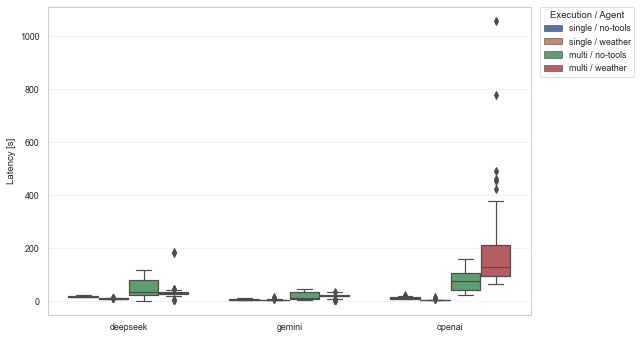

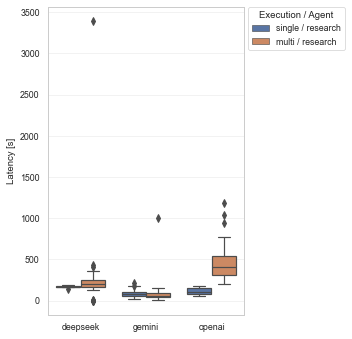

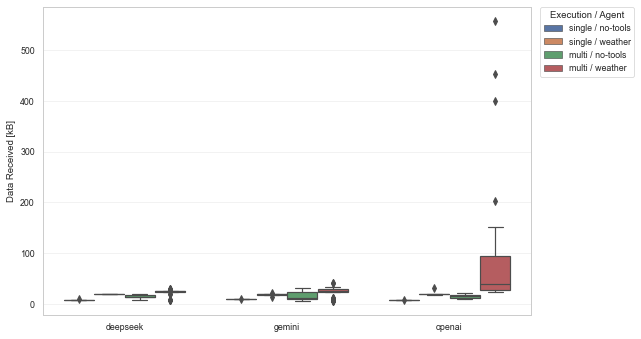

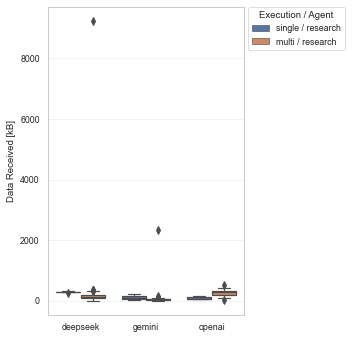

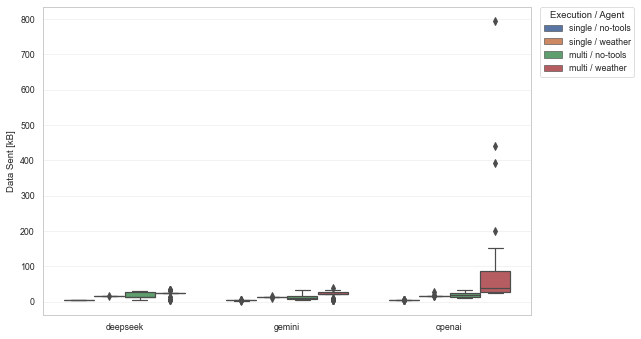

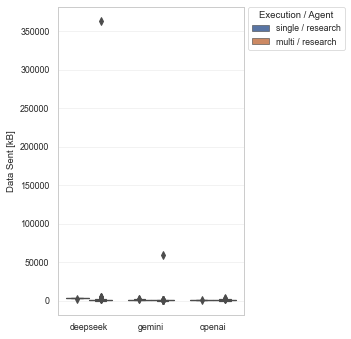

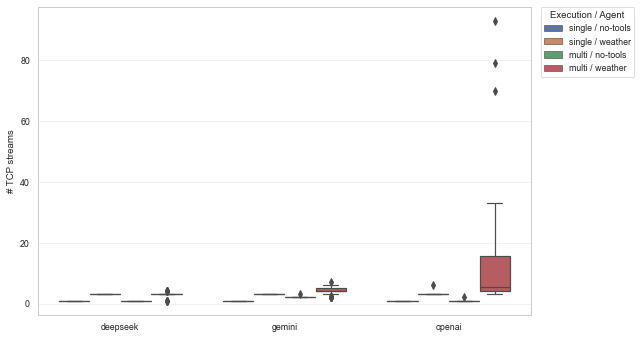

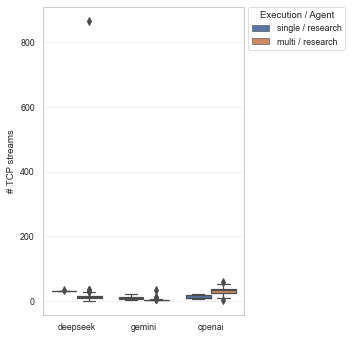

In [26]:
boxplot_y_single_multi_split("latency")
boxplot_y_single_multi_split("received")
boxplot_y_single_multi_split("sent")
boxplot_y_single_multi_split("streams")

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def boxplot_y_log_split(y):
    """
    Create log-scale boxplots comparing single vs multi-agent.

    Produces:
      1) no-tools + weather (same figure)
      2) research only (separate figure)

    Requires:
      single_df, multi_df
    """

    required_cols = {"backend", "prompt", y}

    for name, df in [("single_df", single_df), ("multi_df", multi_df)]:
        missing = required_cols - set(df.columns)
        if missing:
            raise ValueError(f"{name} is missing columns: {missing}")

    # Copy and label execution type
    s_df = single_df.copy()
    m_df = multi_df.copy()

    s_df["execution"] = "single"
    m_df["execution"] = "multi"

    # Merge
    df_all = pd.concat([s_df, m_df], ignore_index=True)

    # Create combined legend label
    df_all["agent_setting"] = (
        df_all["execution"] + " / " + df_all["prompt"]
    )

    # Order
    backend_order = ["deepseek", "gemini", "openai"]
    backend_order = [b for b in backend_order if b in df_all["backend"].unique()]

    # Labels
    if y == "latency":
        y_label = "Latency [s]"
    elif y == "sent":
        y_label = "Data Sent [kB]"
    elif y == "received":
        y_label = "Data Received [kB]"
    elif y == "streams":
        y_label = "# TCP streams"
    else:
        y_label = y

    def plot_subset(prompts, filename_suffix, figsize):
        subset = df_all[df_all["prompt"].isin(prompts)].copy()

        if subset.empty:
            print(f"No data for {prompts}")
            return

        # Avoid log(0)
        subset = subset[subset[y] > 0]

        hue_order = []
        for execution in ["single", "multi"]:
            for prompt in prompts:
                label = f"{execution} / {prompt}"
                if label in subset["agent_setting"].unique():
                    hue_order.append(label)

        fig, ax = plt.subplots(figsize=figsize)

        sns.boxplot(
            data=subset,
            x="backend",
            y=y,
            hue="agent_setting",
            order=backend_order,
            hue_order=hue_order,
            width=0.75,
            ax=ax
        )

        # 🔥 LOG SCALE
        ax.set_yscale("log")

        ax.set_xlabel(None)
        ax.set_ylabel(y_label + " (log scale)")
        ax.grid(axis="y", alpha=0.3, which="both")

        ax.legend(
            title="Execution / Agent",
            loc="upper left",
            bbox_to_anchor=(1.02, 1),
            borderaxespad=0
        )

        fig.tight_layout()

        if SAVE_PLOTS:
            fig.savefig(
                f"{SAVE_DIR}boxplot_{y}_log_{filename_suffix}.png",
                dpi=300,
                bbox_inches="tight"
            )

        plt.show()

    # Figure 1: no-tools + weather
    plot_subset(
        prompts=["no-tools", "weather"],
        filename_suffix="no-tools_weather",
        figsize=(9, 4.8)
    )

    # Figure 2: research
    plot_subset(
        prompts=["research"],
        filename_suffix="research",
        figsize=(5, 4.8)
    )

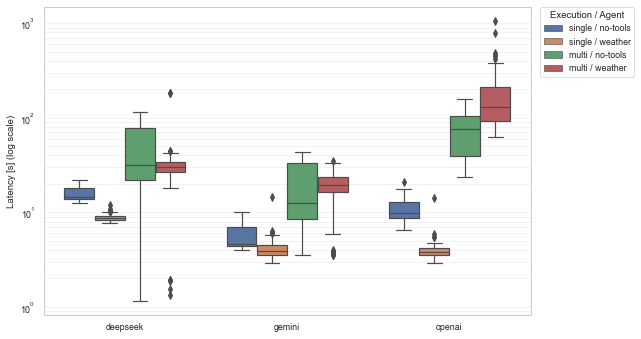

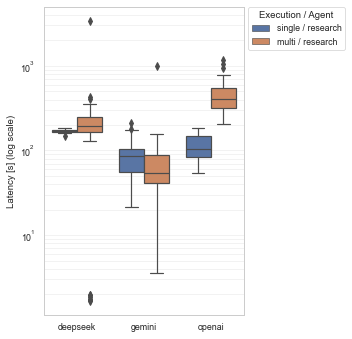

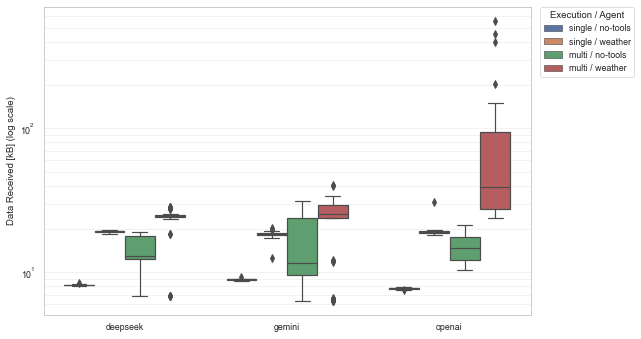

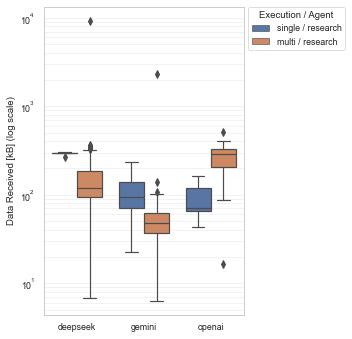

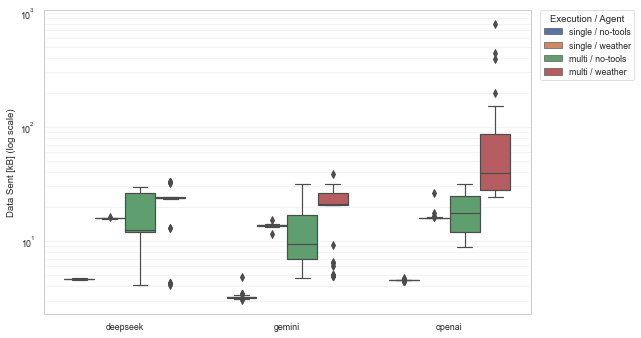

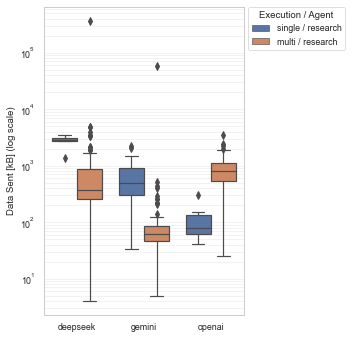

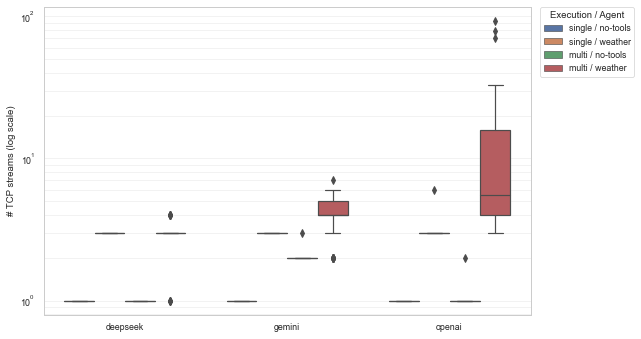

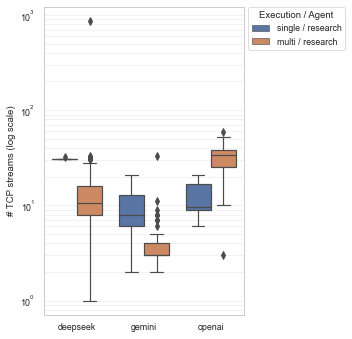

In [28]:
boxplot_y_log_split("latency")
boxplot_y_log_split("received")
boxplot_y_log_split("sent")
boxplot_y_log_split("streams")

In [29]:
def boxplot_y_log_all_tasks(y):
    """
    Create one log-scale boxplot per metric comparing:
      single / no-tools
      single / weather
      single / research
      multi / no-tools
      multi / weather
      multi / research
    """

    required_cols = {"backend", "prompt", y}

    for name, df in [("single_df", single_df), ("multi_df", multi_df)]:
        missing = required_cols - set(df.columns)
        if missing:
            raise ValueError(f"{name} is missing columns: {missing}")

    s_df = single_df.copy()
    m_df = multi_df.copy()

    s_df["execution"] = "single"
    m_df["execution"] = "multi"

    df_all = pd.concat([s_df, m_df], ignore_index=True)

    # Avoid zero values on log scale
    df_all = df_all[df_all[y] > 0].copy()

    df_all["agent_setting"] = (
        df_all["execution"] + " / " + df_all["prompt"]
    )

    backend_order = ["deepseek", "gemini", "openai"]
    backend_order = [b for b in backend_order if b in df_all["backend"].unique()]

    prompt_order = ["no-tools", "weather", "research"]
    execution_order = ["single", "multi"]

    hue_order = [
        f"{execution} / {prompt}"
        for execution in execution_order
        for prompt in prompt_order
        if f"{execution} / {prompt}" in df_all["agent_setting"].unique()
    ]

    if y == "latency":
        y_label = "Latency [s]"
    elif y == "sent":
        y_label = "Data Sent [kB]"
    elif y == "received":
        y_label = "Data Received [kB]"
    elif y == "streams":
        y_label = "# TCP streams"
    else:
        y_label = y

    fig, ax = plt.subplots(figsize=(11, 5))

    sns.boxplot(
        data=df_all,
        x="backend",
        y=y,
        hue="agent_setting",
        order=backend_order,
        hue_order=hue_order,
        width=0.8,
        ax=ax
    )

    ax.set_yscale("log")
    ax.set_xlabel(None)
    ax.set_ylabel(y_label + " (log scale)")
    ax.grid(axis="y", alpha=0.3, which="both")

    ax.legend(
        title="Execution / Agent",
        loc="upper left",
        bbox_to_anchor=(1.02, 1),
        borderaxespad=0
    )

    fig.tight_layout()

    if SAVE_PLOTS:
        fig.savefig(
            f"{SAVE_DIR}boxplot_{y}_log_all_tasks.png",
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

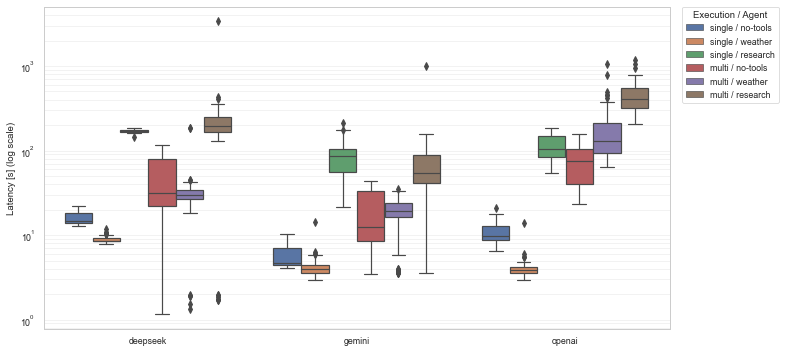

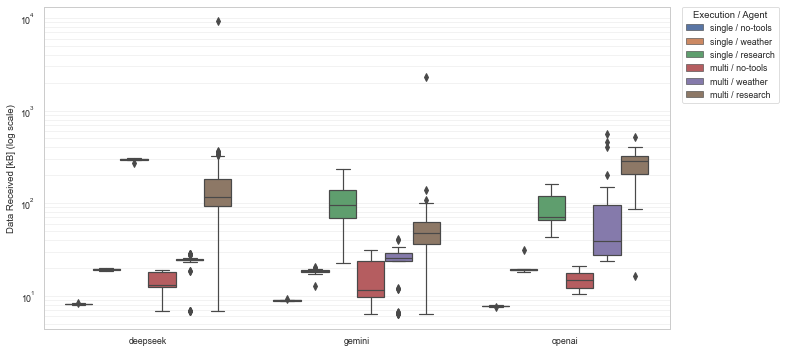

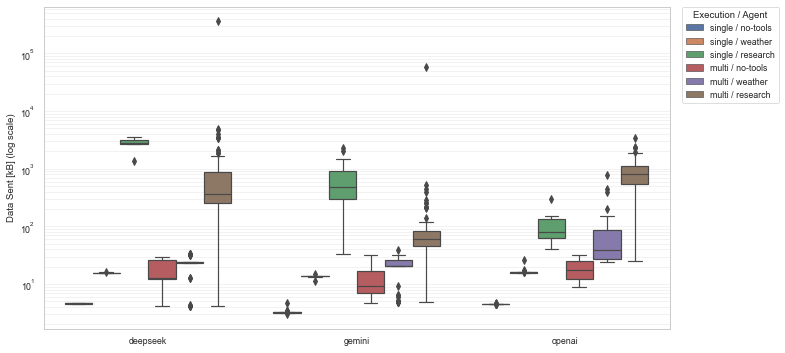

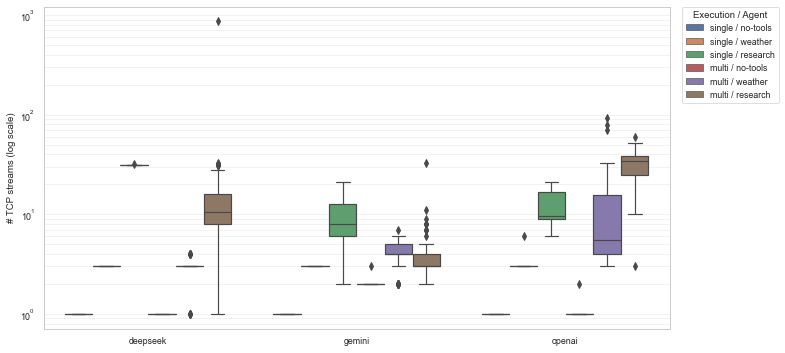

In [30]:
boxplot_y_log_all_tasks("latency")
boxplot_y_log_all_tasks("received")
boxplot_y_log_all_tasks("sent")
boxplot_y_log_all_tasks("streams")

In [34]:
def boxplot_y_log_all_tasks_paired(y):
    """
    One log-scale boxplot per metric.
    Color = task, shade = execution:
      dark = single
      light = multi
    """

    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt

    required_cols = {"backend", "prompt", y}

    for name, df in [("single_df", single_df), ("multi_df", multi_df)]:
        missing = required_cols - set(df.columns)
        if missing:
            raise ValueError(f"{name} is missing columns: {missing}")

    s_df = single_df.copy()
    m_df = multi_df.copy()

    s_df["execution"] = "single"
    m_df["execution"] = "multi"

    df_all = pd.concat([s_df, m_df], ignore_index=True)
    df_all = df_all[df_all[y] > 0].copy()

    df_all["setting"] = df_all["execution"] + " / " + df_all["prompt"]

    backend_order = ["deepseek", "gemini", "openai"]
    backend_order = [b for b in backend_order if b in df_all["backend"].unique()]

    hue_order = [
        "single / no-tools",
        "multi / no-tools",
        "single / weather",
        "multi / weather",
        "single / research",
        "multi / research",
    ]
    hue_order = [h for h in hue_order if h in df_all["setting"].unique()]

    palette = {
        "single / no-tools": "#238b45",
        "multi / no-tools": "#a1d99b",
        "single / weather": "#d95f0e",
        "multi / weather": "#fdae6b",
        "single / research": "#2171b5",
        "multi / research": "#9ecae1",
    }

    labels = {
        "latency": "Latency [s]",
        "sent": "Data Sent [kB]",
        "received": "Data Received [kB]",
        "streams": "# TCP streams",
    }
    y_label = labels.get(y, y)

    fig, ax = plt.subplots(figsize=(12, 5))

    sns.boxplot(
        data=df_all,
        x="backend",
        y=y,
        hue="setting",
        order=backend_order,
        hue_order=hue_order,
        palette=palette,
        width=0.82,
        linewidth=1,
        fliersize=3,
        ax=ax
    )

    ax.set_yscale("log")
    ax.set_xlabel(None)
    ax.set_ylabel(y_label + " (log scale)")
    ax.grid(axis="y", alpha=0.3, which="both")

    ax.legend(
        title="Execution / Task",
        loc="upper left",
        bbox_to_anchor=(1.01, 1),
        borderaxespad=0,
        fontsize=8,
        title_fontsize=9
    )

    fig.tight_layout()

    if SAVE_PLOTS:
        fig.savefig(
            f"{SAVE_DIR}boxplot_{y}_log_paired.png",
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

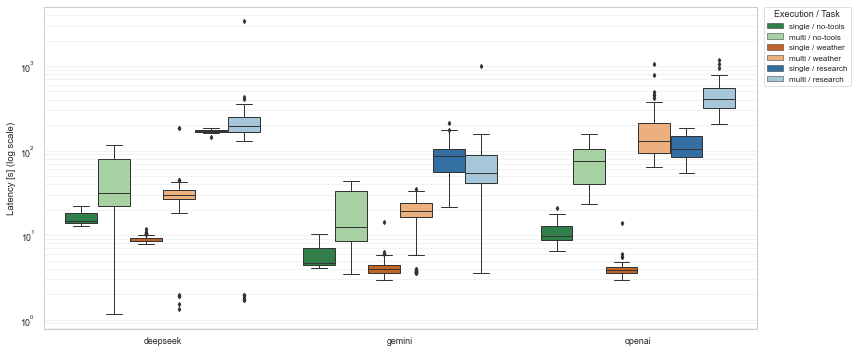

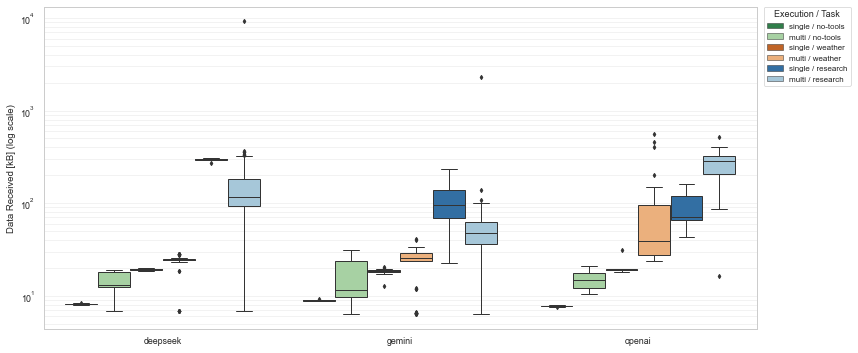

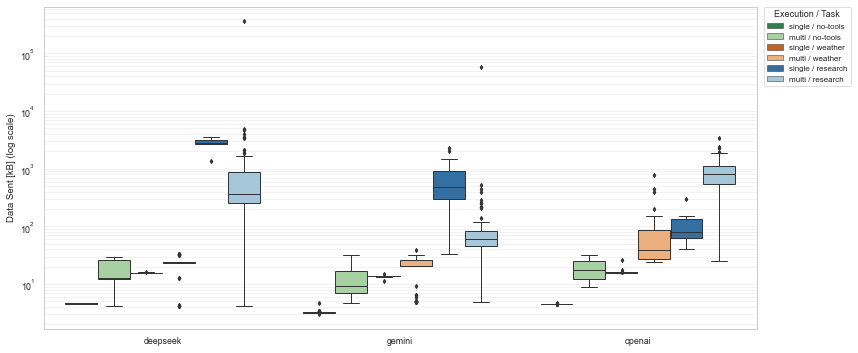

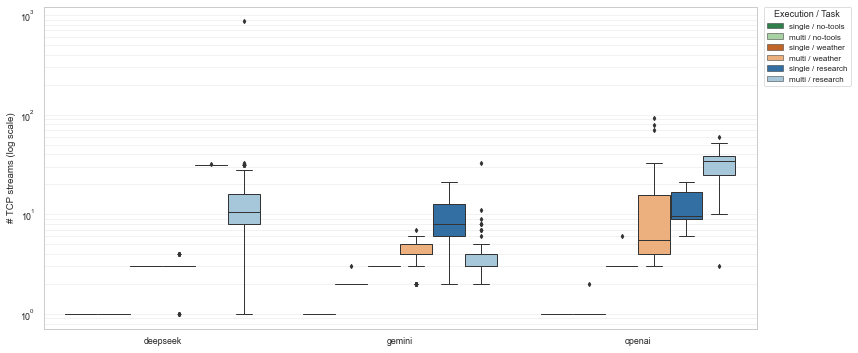

In [35]:
boxplot_y_log_all_tasks_paired("latency")
boxplot_y_log_all_tasks_paired("received")
boxplot_y_log_all_tasks_paired("sent")
boxplot_y_log_all_tasks_paired("streams")

In [44]:
def boxplot_y_log_separate_exec(y):
    """
    Create two figures per metric:
      1) Single-agent
      2) Multi-agent

    Same colors, same scale → easy comparison
    """

    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt

    required_cols = {"backend", "prompt", y}

    for name, df in [("single_df", single_df), ("multi_df", multi_df)]:
        missing = required_cols - set(df.columns)
        if missing:
            raise ValueError(f"{name} is missing columns: {missing}")

    # Labels
    labels = {
        "latency": "Latency [s]",
        "sent": "Data Sent [kB]",
        "received": "Data Received [kB]",
        "streams": "# TCP streams",
    }
    y_label = labels.get(y, y)

    backend_order = ["deepseek", "gemini", "openai"]

    # Consistent colors (same across both figures)
    palette = {
        "no-tools": "#2ca02c",   # green
        "weather": "#ff7f0e",    # orange
        "research": "#1f77b4"    # blue
    }

    def plot(df, title, filename_suffix):
        df = df.copy()
        df = df[df[y] > 0]  # for log scale

        fig, ax = plt.subplots(figsize=(5.2, 3.0))

        sns.boxplot(
            data=df,
            x="backend",
            y=y,
            hue="prompt",
            order=backend_order,
            palette=palette,
            width=0.75,
            ax=ax
        )

        ax.set_yscale("log")
        ax.set_xlabel(None)
        ax.set_ylabel(y_label + " (log scale)")
        #ax.set_title(title)
        ax.grid(axis="y", alpha=0.3, which="both")

        ax.legend(title="Task")

        fig.tight_layout()

        if SAVE_PLOTS:
            fig.savefig(
                f"{SAVE_DIR}boxplot_{y}_{filename_suffix}.png",
                dpi=300,
                bbox_inches="tight"
            )

        plt.show()

    # Plot single-agent
    plot(single_df, "Single-Agent", f"{y}_single")

    # Plot multi-agent
    plot(multi_df, "Multi-Agent", f"{y}_multi")

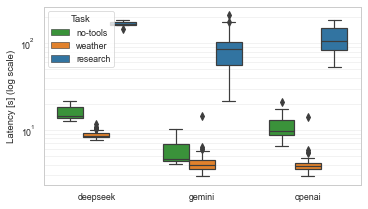

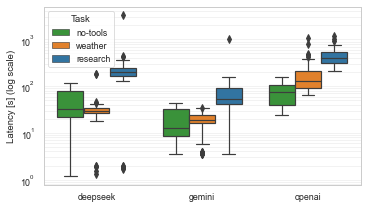

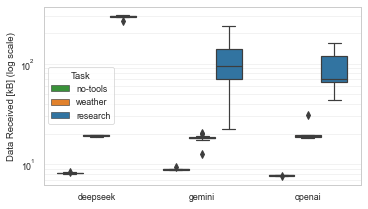

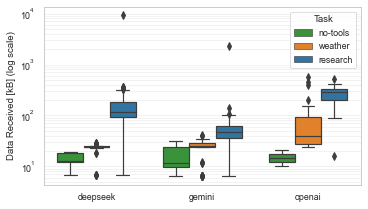

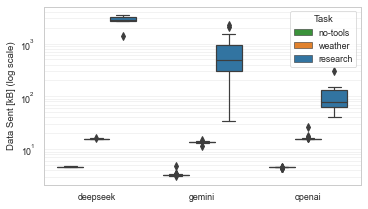

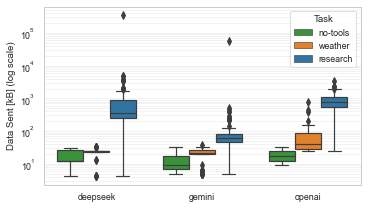

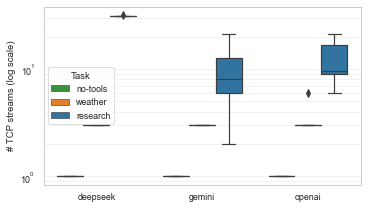

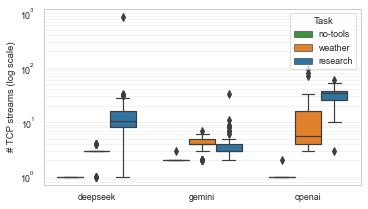

In [45]:
boxplot_y_log_separate_exec("latency")
boxplot_y_log_separate_exec("received")
boxplot_y_log_separate_exec("sent")
boxplot_y_log_separate_exec("streams")

# burstiness

In [46]:
WINDOW_SIZE = 0.01  # seconds
MAX_MATRIX_LEN = 18000  # max number of windows in MTAM

results = []

for prompt in ["no-tools", "weather", "research"]:
    prompt_dir = os.path.join(f"/Users/azza/Desktop/AI agents/multi_agent/pcaps/", f"{prompt}")

    files = [p for p in Path(prompt_dir).iterdir() 
            if p.is_file() and p.suffix.lower() in (".pcap", ".pcapng")]
    
    rng = random.Random(42)
    rng.shuffle(files)
    files = files[:100]  # Limit to first 'x' files for quicker processing

    for p in tqdm(files, desc=f"Processing {prompt_dir}"):
        backend, model, dt = extract_agent_from_filename(p.name)
        packet_trace = pt.pcap_to_trace_scapy(str(p), client_ip = CLIENT_IP)
        analysis = pt.burst_analysis(packet_trace)
        analysis["prompt"] = prompt
        analysis["backend"] = backend
        analysis["model"] = model
        analysis["datetime"] = dt

        # Reuse mtam for short burst analysis
        mtam = pt.build_mtam(packet_trace, window_size=WINDOW_SIZE, num_windows=MAX_MATRIX_LEN)
        window_bursts = pt.window_bursts(mtam)
        analysis["window_bursts"] = window_bursts
        results.append(analysis)


burst_multi_df = pd.DataFrame(results)

Processing /Users/azza/Desktop/AI agents/multi_agent/pcaps/no-tools:   4%|▍         | 4/100 [00:00<00:12,  8.00it/s]

*** Warning: less than 80% of packets involve client_ip='172.17.0.2' (37 out of 50)
*** Warning: less than 80% of packets involve client_ip='172.17.0.2' (59 out of 81)


Processing /Users/azza/Desktop/AI agents/multi_agent/pcaps/no-tools:  14%|█▍        | 14/100 [00:00<00:05, 15.26it/s]

*** Warning: less than 80% of packets involve client_ip='172.17.0.2' (58 out of 76)
*** Warning: less than 80% of packets involve client_ip='172.17.0.2' (70 out of 88)


Processing /Users/azza/Desktop/AI agents/multi_agent/pcaps/no-tools:  21%|██        | 21/100 [00:00<00:04, 19.67it/s]

...

*** Warning: trace length exceeds num_windows (27954 > 18000)


Processing /Users/azza/Desktop/AI agents/multi_agent/pcaps/research:  98%|█████████▊| 98/100 [00:15<00:00,  6.00it/s]

*** Warning: trace length exceeds num_windows (37052 > 18000)
*** Warning: trace length exceeds num_windows (21674 > 18000)


Processing /Users/azza/Desktop/AI agents/multi_agent/pcaps/research: 100%|██████████| 100/100 [00:16<00:00,  6.22it/s]

*** Warning: trace length exceeds num_windows (26271 > 18000)


In [47]:
WINDOW_SIZE = 0.01  # seconds
MAX_MATRIX_LEN = 18000  # max number of windows in MTAM

results = []

for prompt in ["no-tools", "weather", "research"]:
    prompt_dir = os.path.join(f"/Users/azza/Desktop/AI agents/single_agent/", f"{prompt}_agent_train/pcap")

    files = [p for p in Path(prompt_dir).iterdir() 
            if p.is_file() and p.suffix.lower() in (".pcap", ".pcapng")]
    
    rng = random.Random(42)
    rng.shuffle(files)
    files = files[:100]  # Limit to first 'x' files for quicker processing

    for p in tqdm(files, desc=f"Processing {prompt_dir}"):
        backend, model, dt = pt.extract_agent_from_filename(p.name)
        packet_trace = pt.pcap_to_trace_scapy(str(p), client_ip = CLIENT_IP)
        analysis = pt.burst_analysis(packet_trace)
        analysis["prompt"] = prompt
        analysis["backend"] = backend
        analysis["model"] = model
        analysis["datetime"] = dt

        # Reuse mtam for short burst analysis
        mtam = pt.build_mtam(packet_trace, window_size=WINDOW_SIZE, num_windows=MAX_MATRIX_LEN)
        window_bursts = pt.window_bursts(mtam)
        analysis["window_bursts"] = window_bursts
        results.append(analysis)


burst_single_df = pd.DataFrame(results)

Processing /Users/azza/Desktop/AI agents/single_agent/no-tools_agent_train/pcap:   3%|▎         | 3/100 [00:00<00:03, 26.72it/s]

*** Warning: less than 80% of packets involve client_ip='172.17.0.2' (27 out of 40)
*** Warning: less than 80% of packets involve client_ip='172.17.0.2' (33 out of 45)
*** Warning: less than 80% of packets involve client_ip='172.17.0.2' (34 out of 44)
*** Warning: less than 80% of packets involve client_ip='172.17.0.2' (32 out of 50)
*** Warning: less than 80% of packets involve client_ip='172.17.0.2' (25 out of 35)
*** Warning: less than 80% of packets involve client_ip='172.17.0.2' (25 out of 42)
*** Warning: less than 80% of packets involve client_ip='172.17.0.2' (32 out of 47)


Processing /Users/azza/Desktop/AI agents/single_agent/no-tools_agent_train/pcap:  11%|█         | 11/100 [00:00<00:03, 29.06it/s]

*** Warning: less than 80% of packets involve client_ip='172.17.0.2' (31 out of 43)
*** Warning: less than 80% of packets involve client_ip='172.17.0.2' (24 out of 41)
*** Warning: less than 80% of packets involve client_ip='172.17.0.2' (30 out of 44)
*** Warning: less than 80% of packets involve client_ip='172.17.0.2' (27 out of 45)
*** Warning: less than 80% of packets involve client_ip='172.17.0.2' (29 out of 39)
*** Warning: less than 80% of packets involve client_ip='172.17.0.2' (27 out of 44)


Processing /Users/azza/Desktop/AI agents/single_agent/no-tools_agent_train/pcap:  19%|█▉        | 19/100 [00:00<00:02, 30.62it/s]

...

Processing /Users/azza/Desktop/AI agents/single_agent/research_agent_train/pcap:  66%|██████▌   | 37/56 [00:05<00:02,  9.00it/s]

*** Warning: trace length exceeds num_windows (18507 > 18000)


Processing /Users/azza/Desktop/AI agents/single_agent/research_agent_train/pcap:  82%|████████▏ | 46/56 [00:07<00:01,  5.35it/s]

*** Warning: trace length exceeds num_windows (21264 > 18000)


Processing /Users/azza/Desktop/AI agents/single_agent/research_agent_train/pcap: 100%|██████████| 56/56 [00:09<00:00,  6.15it/s]


In [49]:
burst_multi_df.head()

,num_bursts,avg_burst_size,avg_burst_duration,bursts,prompt,backend,model,datetime,window_bursts
0,2,6101.50,0.42,"[(10483, 0.6516251564025879), (1720, 0.1838929...",no-tools,gemini,gemini-2.5-pro,20260421-152601,"[186, 580, 723, 5321, 74, 2643, 206, 66, 66, 1..."
1,5,5369.80,0.02,"[(8786, 0.05779600143432617), (5681, 0.0147941...",no-tools,openai,gpt-5,20260422-220258,"[491, 8229, 66, 2780, 2901, 3086, 2662, 1730, ..."
2,5,5013.00,0.02,"[(8922, 0.0534970760345459), (5642, 0.01508903...",no-tools,openai,gpt-5,20260422-151101,"[6509, 2347, 66, 2781, 2729, 132, 4734, 4154, ..."
3,7,5889.00,0.29,"[(355, 0.2670741081237793), (11269, 0.39155387...",no-tools,deepseek,deepseek-chat,20260421-135008,"[152, 203, 8045, 2404, 754, 66, 1126, 682, 196..."
4,6,6653.83,0.02,"[(8915, 0.053502798080444336), (6415, 0.014178...",no-tools,openai,gpt-5,20260421-112453,"[6509, 2340, 66, 2966, 3317, 132, 2385, 4721, ..."


In [50]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_burst_size_duration_single_multi():
    """
    Plot burst size vs. duration for single-agent and multi-agent executions.
    Uses two panels with shared log-scale axes.
    """

    required_cols = {"bursts", "prompt", "backend"}

    for name, df in [("burst_single_df", burst_single_df), ("burst_multi_df", burst_multi_df)]:
        missing = required_cols - set(df.columns)
        if missing:
            raise ValueError(f"{name} is missing columns: {missing}")

    # Add execution labels
    single = burst_single_df.copy()
    multi = burst_multi_df.copy()

    single["execution"] = "Single-agent"
    multi["execution"] = "Multi-agent"

    burst_df_all = pd.concat([single, multi], ignore_index=True)

    # One row per burst
    df_plot = burst_df_all.explode("bursts", ignore_index=True)

    # Remove empty bursts if any
    df_plot = df_plot[df_plot["bursts"].notna()].copy()

    # Split tuple/list into size and duration
    df_plot[["size", "duration"]] = pd.DataFrame(
        df_plot["bursts"].tolist(),
        index=df_plot.index
    )

    # Keep only positive values for log scale
    df_plot = df_plot[(df_plot["size"] > 0) & (df_plot["duration"] > 0)].copy()

    # Rename for plotting
    df_plot = df_plot.rename(columns={
        "backend": "Model",
        "prompt": "Prompt",
        "execution": "Execution"
    })

    # Shuffle for fair overplotting
    df_plot = df_plot.sample(frac=1, random_state=42)

    fig, axes = plt.subplots(
        1, 2,
        figsize=(9, 4),
        sharex=True,
        sharey=True
    )

    for ax, execution in zip(axes, ["Single-agent", "Multi-agent"]):
        subset = df_plot[df_plot["Execution"] == execution]

        sns.scatterplot(
            data=subset,
            x="duration",
            y="size",
            hue="Model",
            style="Prompt",
            s=18,
            alpha=0.45,
            ax=ax
        )

        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_title(execution)
        ax.set_xlabel("Duration [s]")
        ax.set_ylabel("Size [bytes]" if execution == "Single-agent" else "")
        ax.grid(alpha=0.3, which="both")

        # Remove duplicate legends from first panel
        if execution == "Single-agent":
            ax.legend_.remove()
        else:
            ax.legend(
                title=None,
                loc="upper left",
                bbox_to_anchor=(1.02, 1),
                borderaxespad=0,
                fontsize=8
            )

    fig.tight_layout()

    if SAVE_PLOTS:
        fig.savefig(
            f"{SAVE_DIR}burst_size_vs_duration_single_multi.png",
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

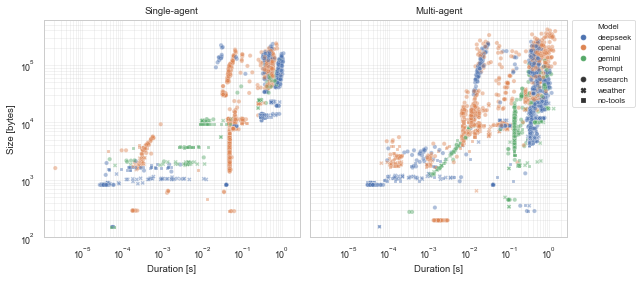

In [51]:
plot_burst_size_duration_single_multi()

In [52]:
import pandas as pd

def burst_summary_stats():
    def prepare(df, execution):
        df = df.copy()
        df["execution"] = execution
        df = df.explode("bursts", ignore_index=True)
        df = df[df["bursts"].notna()].copy()

        df[["size", "duration"]] = pd.DataFrame(
            df["bursts"].tolist(),
            index=df.index
        )

        df = df[(df["size"] > 0) & (df["duration"] > 0)].copy()
        return df

    single = prepare(burst_single_df, "single")
    multi = prepare(burst_multi_df, "multi")

    df_all = pd.concat([single, multi], ignore_index=True)

    summary = (
        df_all
        .groupby("execution")
        .agg(
            median_burst_size_bytes=("size", "median"),
            median_burst_duration_s=("duration", "median"),
            mean_burst_size_bytes=("size", "mean"),
            mean_burst_duration_s=("duration", "mean"),
            num_bursts=("size", "count")
        )
        .reset_index()
    )

    single_row = summary[summary["execution"] == "single"].iloc[0]
    multi_row = summary[summary["execution"] == "multi"].iloc[0]

    size_ratio = (
        multi_row["median_burst_size_bytes"] /
        single_row["median_burst_size_bytes"]
    )

    duration_ratio = (
        multi_row["median_burst_duration_s"] /
        single_row["median_burst_duration_s"]
    )

    print(summary)
    print()
    print(f"Median burst size increase: {size_ratio:.2f}x")
    print(f"Median burst duration increase: {duration_ratio:.2f}x")

    return summary, size_ratio, duration_ratio

summary, size_ratio, duration_ratio = burst_summary_stats()

  execution  median_burst_size_bytes  median_burst_duration_s  \
0     multi                   9836.5                 0.138775   
1    single                  10666.0                 0.056713   

   mean_burst_size_bytes  mean_burst_duration_s  num_bursts  
0           31817.971375               0.246841        3214  
1           35100.206077               0.197162        1810  

Median burst size increase: 0.92x
Median burst duration increase: 2.45x


In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context("paper", font_scale=1.4)  # 1.2–1.6 is good range

plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

In [65]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_burst_size_duration_separate():
    """
    Create two separate figures:
      1) Single-agent burst size vs duration
      2) Multi-agent burst size vs duration
    """

    required_cols = {"bursts", "prompt", "backend"}

    for name, df in [("burst_single_df", burst_single_df), ("burst_multi_df", burst_multi_df)]:
        missing = required_cols - set(df.columns)
        if missing:
            raise ValueError(f"{name} is missing columns: {missing}")

    def prepare(df):
        df = df.copy()

        # Explode bursts
        df = df.explode("bursts", ignore_index=True)
        df = df[df["bursts"].notna()].copy()

        # Split tuple → columns
        df[["size", "duration"]] = pd.DataFrame(
            df["bursts"].tolist(),
            index=df.index
        )

        # Remove invalid values for log scale
        df = df[(df["size"] > 0) & (df["duration"] > 0)].copy()

        # Rename for plotting
        df = df.rename(columns={
            "backend": "Model",
            "prompt": "Prompt"
        })

        # Shuffle (better visualization)
        df = df.sample(frac=1, random_state=42)

        return df

    df_single = prepare(burst_single_df)
    df_multi = prepare(burst_multi_df)

    def plot(df, title, filename):
        plt.figure(figsize=(8, 4.8))

        sns.scatterplot(
            data=df,
            x="duration",
            y="size",
            hue="Model",
            style="Prompt",
            s=20,
            alpha=0.45
        )

        plt.xscale("log")
        plt.yscale("log")
        
        plt.xlabel("Duration [s]", fontsize=12)
        plt.ylabel("Size [bytes]", fontsize=12)

        plt.xticks(fontsize=10)
        plt.yticks(fontsize=10)

        #plt.title(title)

        plt.grid(alpha=0.3, which="both")

        # Cleaner legend
        plt.legend(
            title=None,
            fontsize=9,
            loc="upper left",
            bbox_to_anchor=(1.02, 1),
            borderaxespad=0
        )

        plt.tight_layout(pad=0.5)

        if SAVE_PLOTS:
            plt.savefig(
                f"{SAVE_DIR}{filename}.png",
                dpi=300,
                bbox_inches="tight"
            )

        plt.show()

    # Plot single-agent
    plot(df_single, "Single-agent", "burst_size_vs_duration_single")

    # Plot multi-agent
    plot(df_multi, "Multi-agent", "burst_size_vs_duration_multi")

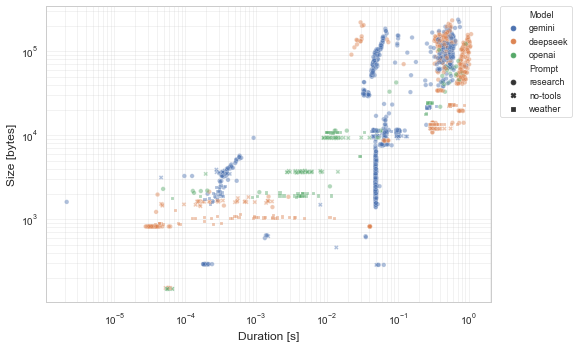

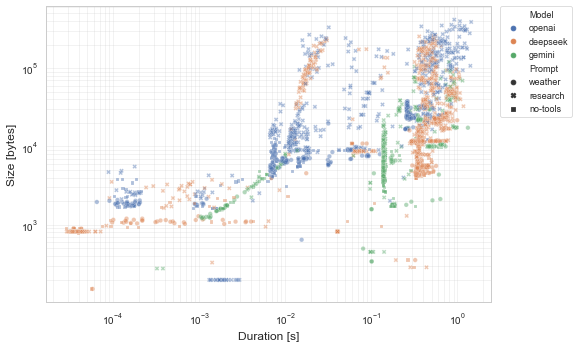

In [66]:
plot_burst_size_duration_separate()

In [ ]:
plt.figure(figsize=(5.2, 3.2))

sns.scatterplot(
    data=df,
    x="duration",
    y="size",
    hue="Model",
    style="Prompt",
    s=25,              # increase marker size
    alpha=0.6
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Duration [s]", fontsize=12)
plt.ylabel("Size [bytes]", fontsize=12)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.grid(alpha=0.3, which="both")

plt.legend(
    fontsize=9,
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0
)

plt.tight_layout(pad=0.5)

In [77]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_burst_size_duration_separate():
    """
    Create two separate, consistent figures:
      1) Single-agent burst size vs duration
      2) Multi-agent burst size vs duration

    Symbols and colors are fixed across both figures.
    """

    required_cols = {"bursts", "prompt", "backend"}

    for name, df in [("burst_single_df", burst_single_df), ("burst_multi_df", burst_multi_df)]:
        missing = required_cols - set(df.columns)
        if missing:
            raise ValueError(f"{name} is missing columns: {missing}")

    # ---- fixed category order ----
    model_order = ["openai", "gemini", "deepseek"]
    prompt_order = ["weather", "research", "no-tools"]

    # ---- fixed marker mapping ----
    marker_map = {
        "weather": "o",
        "research": "X",
        "no-tools": "s"
    }

    def prepare(df):
        df = df.copy()

        df = df.explode("bursts", ignore_index=True)
        df = df[df["bursts"].notna()].copy()

        df[["size", "duration"]] = pd.DataFrame(
            df["bursts"].tolist(),
            index=df.index
        )

        df = df[(df["size"] > 0) & (df["duration"] > 0)].copy()

        df = df.rename(columns={
            "backend": "Model",
            "prompt": "Prompt"
        })

        # enforce same categorical order in both plots
        df["Model"] = pd.Categorical(df["Model"], categories=model_order, ordered=True)
        df["Prompt"] = pd.Categorical(df["Prompt"], categories=prompt_order, ordered=True)

        df = df.dropna(subset=["Model", "Prompt"])

        return df.sample(frac=1, random_state=42)

    df_single = prepare(burst_single_df)
    df_multi = prepare(burst_multi_df)

    def plot(df, filename):
        plt.figure(figsize=(10, 6.2))  # bigger for paper

        ax = sns.scatterplot(
            data=df,
            x="duration",
            y="size",
            hue="Model",
            hue_order=model_order,
            style="Prompt",
            style_order=prompt_order,
            markers=marker_map,
            s=32,
            alpha=0.55,
            edgecolor=None
        )

        ax.set_xscale("log")
        ax.set_yscale("log")

        ax.set_xlabel("Duration [s]", fontsize=15)
        ax.set_ylabel("Size [bytes]", fontsize=15)

        ax.tick_params(axis="both", which="major", labelsize=13)
        ax.tick_params(axis="both", which="minor", labelsize=11)

        ax.grid(alpha=0.3, which="both")

        # consistent, compact legend
        # ---- custom legend with bold section headers ----
        handles, labels = ax.get_legend_handles_labels()

        new_labels = []
        for lbl in labels:
            if lbl == "Model":
                new_labels.append(r"$\bf{Model}$")
            elif lbl == "Prompt":
                new_labels.append(r"$\bf{Prompt}$")
            else:
                new_labels.append(lbl)

        ax.legend(
            handles,
            new_labels,
            fontsize=12,
            loc="upper left",
            bbox_to_anchor=(1.02, 1),
            borderaxespad=0,
            frameon=True
        )

        plt.tight_layout()

        if SAVE_PLOTS:
                plt.savefig(f"{SAVE_DIR}{filename}.pdf", bbox_inches="tight")
                plt.savefig(f"{SAVE_DIR}{filename}.png", dpi=300, bbox_inches="tight")

        plt.show()

    plot(df_single, "burst_size_vs_duration_single")
    plot(df_multi, "burst_size_vs_duration_multi")

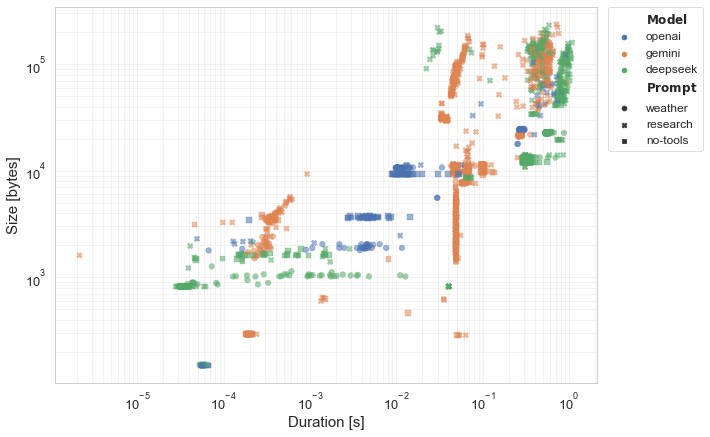

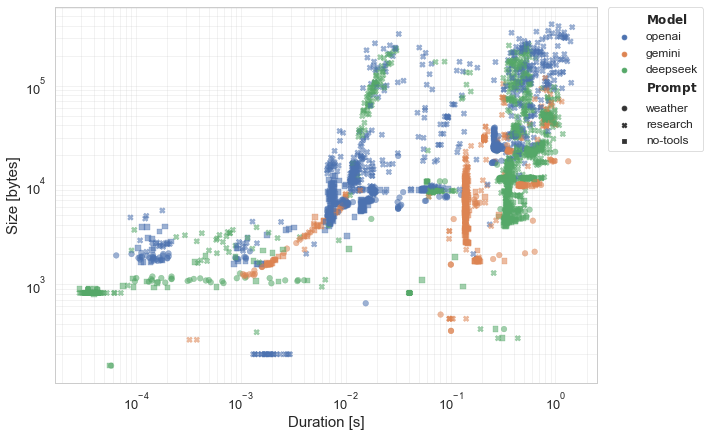

In [78]:
plot_burst_size_duration_separate()